In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/validation/validation.csv
/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/test/test.csv
/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv


In [2]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

from imblearn.combine import SMOTEENN

from xgboost import XGBClassifier


In [3]:
train_path = "/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv"
test_path = "/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/test/test.csv"
val_path = "/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/validation/validation.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
val_df = pd.read_csv(val_path)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Validation:", val_df.shape)

train_df.head()

Train: (5491971, 47)
Test: (1176851, 47)
Validation: (1176851, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [4]:
print(train_df.columns)

for col in train_df.columns:
    if "label" in col.lower() or "class" in col.lower() or "attack" in col.lower():
        print(col, train_df[col].unique()[:20])

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')
label ['DDoS-ACK_Fragmentation' 'DDoS-SYN_Flood' 'DDoS-PSHACK_Flood'
 'Mirai-greeth_flood' 'DoS-SYN_Flood' 'DDoS-ICMP_Flood' 'DDoS-TCP_Flood'
 'DDoS-UDP_Flood' 'Mirai-greip_flood' 'BenignTraffic' 'Mirai-udpplain'
 'DoS-TCP_Flood' 'DDoS-SynonymousIP_Flood' 'DoS-UDP_Flood'
 'DDoS-RSTFINFlood' 'Recon-HostDiscovery' 'DDoS-UDP_Fragmentation'
 'DDoS-ICMP_Fragmentation' 'DDoS-HTTP_Flood' 'MITM-Ar

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH              float64
 25  IRC              float64
 26  TCP              float64
 27  UDP         

In [6]:
label_col = "label"   

# Class Distribution

In [7]:
print(train_df[label_col].value_counts())

label
DDoS-ICMP_Flood            848088
DDoS-UDP_Flood             637558
DDoS-TCP_Flood             528499
DDoS-PSHACK_Flood          481254
DDoS-SYN_Flood             478653
DDoS-RSTFINFlood           475441
DDoS-SynonymousIP_Flood    422083
DoS-UDP_Flood              390422
DoS-TCP_Flood              314174
DoS-SYN_Flood              237573
BenignTraffic              129538
Mirai-greeth_flood         116133
Mirai-udpplain             104814
Mirai-greip_flood           88821
DDoS-ICMP_Fragmentation     53046
MITM-ArpSpoofing            36316
DDoS-UDP_Fragmentation      34169
DDoS-ACK_Fragmentation      33581
DNS_Spoofing                21214
Recon-HostDiscovery         15737
Recon-OSScan                11587
Recon-PortScan               9648
DoS-HTTP_Flood               8487
VulnerabilityScan            4396
DDoS-HTTP_Flood              3371
DDoS-SlowLoris               2757
DictionaryBruteForce         1541
BrowserHijacking              665
CommandInjection              620
SqlInjec

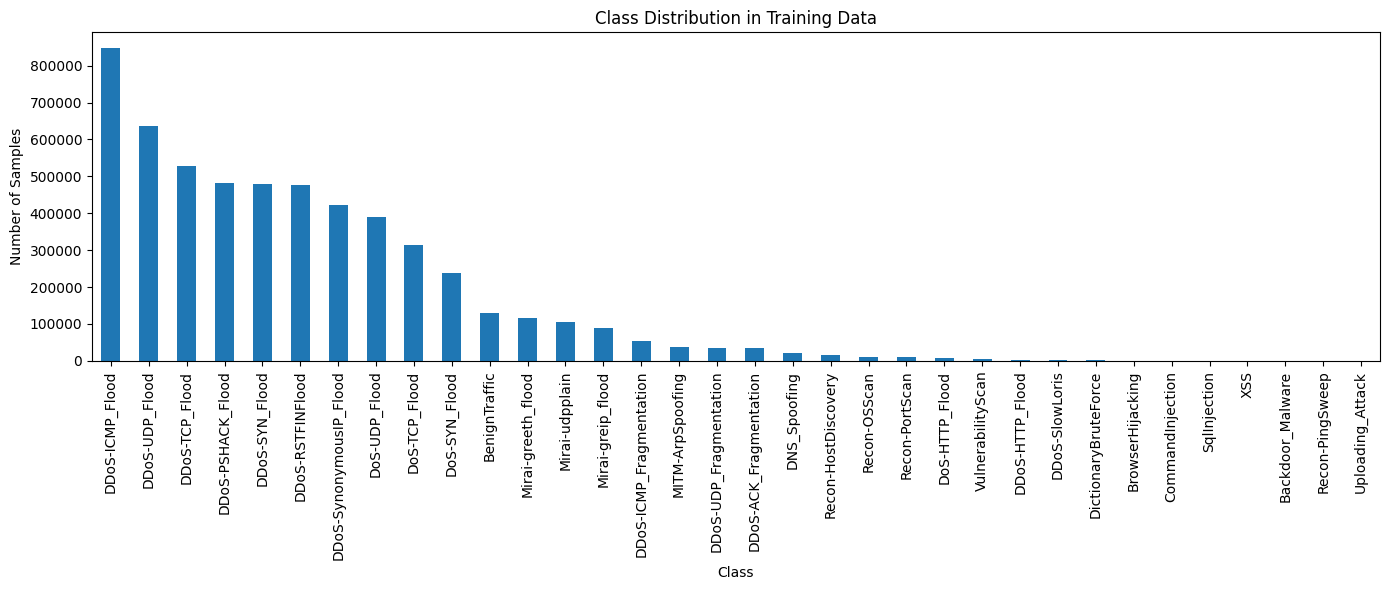

In [8]:
plt.figure(figsize=(14,6))
train_df[label_col].value_counts().plot(kind="bar")
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=400)
plt.show()

# Combine Train and Validation

In [9]:
train_full_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

print("Combined Train + Validation:", train_full_df.shape)
print("Test:", test_df.shape)

Combined Train + Validation: (6668822, 47)
Test: (1176851, 47)


# Data Preprocessing

In [10]:
def clean_data(df):
    df = df.copy()
    df = df.drop_duplicates()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    return df

train_full_df = clean_data(train_full_df)
test_df = clean_data(test_df)

print("Cleaned Train:", train_full_df.shape)
print("Cleaned Test:", test_df.shape)

Cleaned Train: (6470216, 47)
Cleaned Test: (1170467, 47)


In [11]:
X_train = train_full_df.drop(columns=[label_col])
y_train = train_full_df[label_col]

X_test = test_df.drop(columns=[label_col])
y_test = test_df[label_col]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6470216, 46) (6470216,)
(1170467, 46) (1170467,)


Encode Categorical Features

In [12]:
for col in X_train.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str)
    
    X_test[col] = X_test[col].apply(lambda x: x if x in le.classes_ else "unknown")
    
    if "unknown" not in le.classes_:
        le.classes_ = np.append(le.classes_, "unknown")
    
    X_test[col] = le.transform(X_test[col])

In [13]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("Classes:")
print(target_encoder.classes_)

Classes:
['Backdoor_Malware' 'BenignTraffic' 'BrowserHijacking' 'CommandInjection'
 'DDoS-ACK_Fragmentation' 'DDoS-HTTP_Flood' 'DDoS-ICMP_Flood'
 'DDoS-ICMP_Fragmentation' 'DDoS-PSHACK_Flood' 'DDoS-RSTFINFlood'
 'DDoS-SYN_Flood' 'DDoS-SlowLoris' 'DDoS-SynonymousIP_Flood'
 'DDoS-TCP_Flood' 'DDoS-UDP_Flood' 'DDoS-UDP_Fragmentation' 'DNS_Spoofing'
 'DictionaryBruteForce' 'DoS-HTTP_Flood' 'DoS-SYN_Flood' 'DoS-TCP_Flood'
 'DoS-UDP_Flood' 'MITM-ArpSpoofing' 'Mirai-greeth_flood'
 'Mirai-greip_flood' 'Mirai-udpplain' 'Recon-HostDiscovery' 'Recon-OSScan'
 'Recon-PingSweep' 'Recon-PortScan' 'SqlInjection' 'Uploading_Attack'
 'VulnerabilityScan' 'XSS']


In [14]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(6470216, 46)
(1170467, 46)


In [15]:
!nvidia-smi

Sun Apr 26 15:40:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# GPU XGBoost Feature Selection


In [16]:
# GPU-based feature selection using XGBoost feature importance.
# This replaces SelectKBest + mutual_info_classif because mutual information is CPU-heavy on CICIoT2023.

k = 20

xgb_fs = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda"
)

xgb_fs.fit(X_train_scaled, y_train_encoded)

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_fs.feature_importances_
}).sort_values(by="Importance", ascending=False)

selected_features = feature_importance_df.head(k)["Feature"].tolist()

print("Selected Features:")
print(selected_features)

X_train_selected_df = X_train[selected_features]
X_test_selected_df = X_test[selected_features]

selected_scaler = MinMaxScaler()

X_train_selected = selected_scaler.fit_transform(X_train_selected_df)
X_test_selected = selected_scaler.transform(X_test_selected_df)

print("Selected Train Shape:", X_train_selected.shape)
print("Selected Test Shape:", X_test_selected.shape)


Selected Features:
['fin_flag_number', 'psh_flag_number', 'ICMP', 'syn_flag_number', 'IAT', 'Protocol Type', 'UDP', 'Weight', 'Rate', 'Min', 'rst_count', 'Tot sum', 'fin_count', 'HTTP', 'SSH', 'Header_Length', 'ack_count', 'Radius', 'syn_count', 'urg_count']
Selected Train Shape: (6470216, 20)
Selected Test Shape: (1170467, 20)


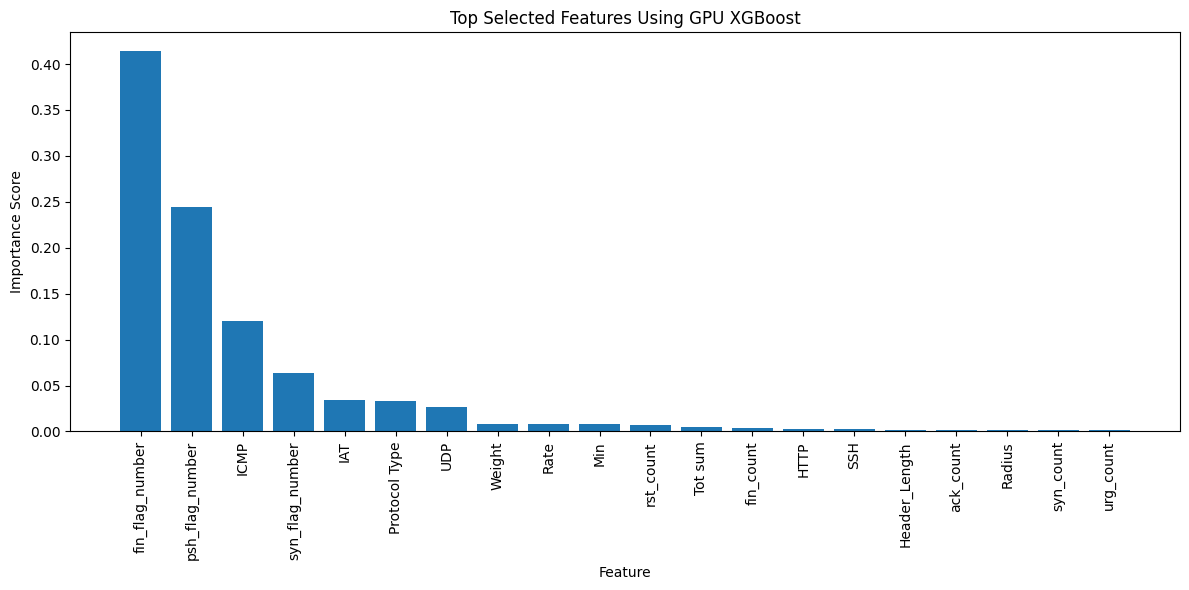

In [17]:
plt.figure(figsize=(12,6))
plt.bar(
    feature_importance_df.head(k)["Feature"],
    feature_importance_df.head(k)["Importance"]
)
plt.title("Top Selected Features Using GPU XGBoost")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("gpu_xgboost_feature_importance_400dpi.png", dpi=400)
plt.show()


In [18]:
k_values = [5, 10, 15, 20]
k_results = []

for k_val in k_values:
    temp_features = feature_importance_df.head(k_val)["Feature"].tolist()

    X_temp_train = X_train[temp_features]
    X_temp_test = X_test[temp_features]

    temp_scaler = MinMaxScaler()
    X_temp_train = temp_scaler.fit_transform(X_temp_train)
    X_temp_test = temp_scaler.transform(X_temp_test)

    temp_model = XGBClassifier(
        n_estimators=80,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda"
    )

    temp_model.fit(X_temp_train, y_train_encoded)
    temp_pred = temp_model.predict(X_temp_test)

    acc = accuracy_score(y_test_encoded, temp_pred)
    k_results.append(acc)

    print(f"K={k_val}, Accuracy={acc:.4f}")


K=5, Accuracy=0.9786
K=10, Accuracy=0.9888
K=15, Accuracy=0.9913
K=20, Accuracy=0.9916


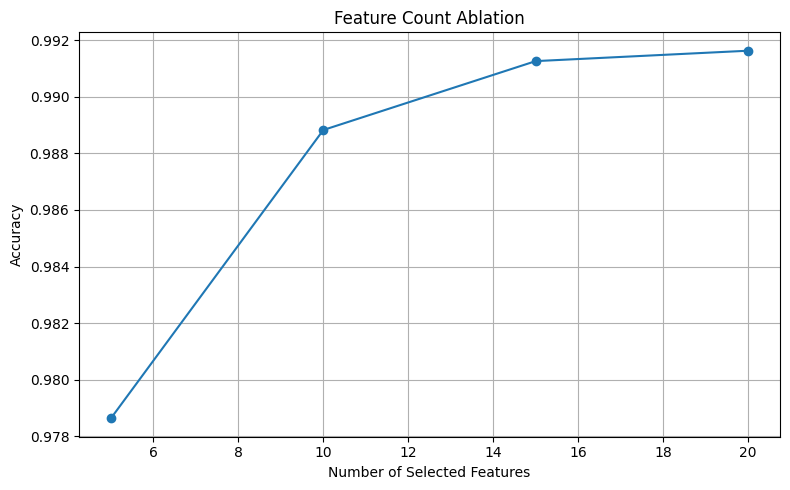

In [19]:
plt.figure(figsize=(8,5))
plt.plot(k_values, k_results, marker="o")
plt.title("Feature Count Ablation")
plt.xlabel("Number of Selected Features")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("feature_count_ablation.png", dpi=400)
plt.show()

# Apply SMOTE-ENN

In [20]:
import pandas as pd
import numpy as np

sample_size = 150000

df_temp = pd.DataFrame(X_train_selected)
df_temp["target"] = y_train_encoded

df_sampled = df_temp.groupby("target", group_keys=False).apply(
    lambda x: x.sample(
        min(len(x), sample_size // df_temp["target"].nunique()),
        random_state=42
    )
)

X_train_selected_small = df_sampled.drop(columns=["target"]).values
y_train_small = df_sampled["target"].values

print(X_train_selected_small.shape)

(118553, 20)


In [21]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)

X_train_balanced, y_train_balanced = smote_enn.fit_resample(
    X_train_selected_small,
    y_train_small
)

print(X_train_balanced.shape)

(108445, 20)


# Base Models

In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

xgb1 = XGBClassifier(
    n_estimators=250,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda"
)

xgb2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=43,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda"
)

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)


# Build Stacking Model

In [32]:
stacking_model = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb1", xgb1),
        ("xgb2", xgb2)
    ],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)


# Train Final Model

In [33]:
start_train = time.time()

stacking_model.fit(X_train_balanced, y_train_balanced)

end_train = time.time()

training_time = end_train - start_train

print("Training Time:", training_time, "seconds")

[16:02:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

[16:03:11] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.



Training Time: 165.63361763954163 seconds


# Test Prediction and Inference Time

In [34]:
start_test = time.time()

y_pred = stacking_model.predict(X_test_selected)

end_test = time.time()

inference_time = end_test - start_test

print("Inference Time:", inference_time, "seconds")

Inference Time: 22.645061254501343 seconds


# Evaluation Metrics

In [35]:
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test_encoded, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test_encoded, y_pred, average="macro", zero_division=0)

print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1-score:", f1)

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))


Accuracy: 0.9783257451940123
Macro Precision: 0.7050636975573092
Macro Recall: 0.8309679564165181
Macro F1-score: 0.6989828379146227
                         precision    recall  f1-score   support

       Backdoor_Malware       0.04      0.66      0.08        88
          BenignTraffic       0.96      0.58      0.72     27571
       BrowserHijacking       0.03      0.76      0.06       133
       CommandInjection       0.05      0.72      0.09       118
 DDoS-ACK_Fragmentation       1.00      0.98      0.99      7262
        DDoS-HTTP_Flood       0.71      0.97      0.82       707
        DDoS-ICMP_Flood       1.00      1.00      1.00    179501
DDoS-ICMP_Fragmentation       0.99      0.98      0.99     11339
      DDoS-PSHACK_Flood       1.00      1.00      1.00    102790
       DDoS-RSTFINFlood       1.00      1.00      1.00    101251
         DDoS-SYN_Flood       1.00      0.99      1.00    101651
         DDoS-SlowLoris       0.93      0.99      0.96       618
DDoS-SynonymousIP_Flo

# Confusion Matrix

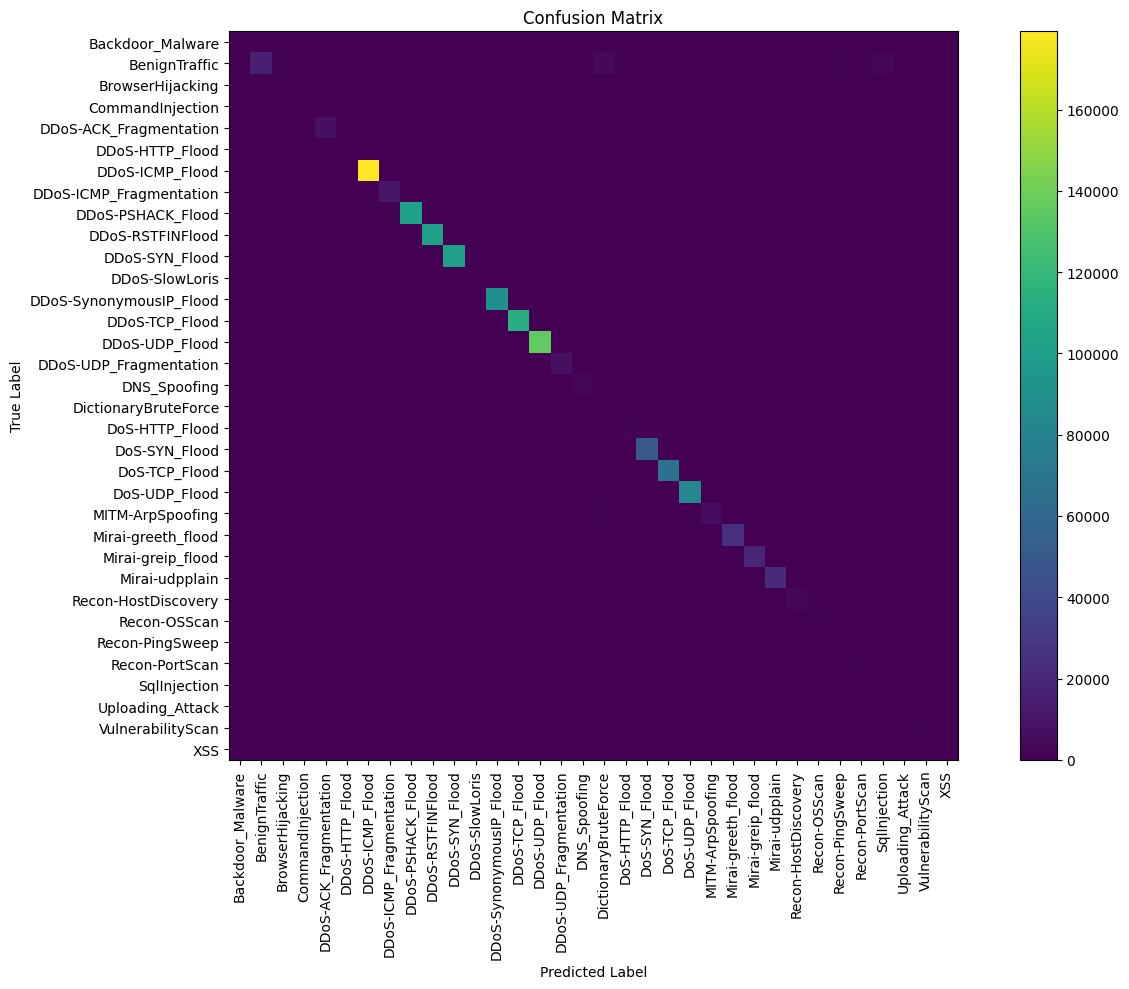

In [36]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(14,10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=np.arange(len(target_encoder.classes_)), labels=target_encoder.classes_, rotation=90)
plt.yticks(ticks=np.arange(len(target_encoder.classes_)), labels=target_encoder.classes_)
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=400)
plt.show()

# Ablation Study

In [37]:
ablation_results = []

# Full Model

In [38]:
ablation_results.append({
    "Configuration": "Full Model",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

# Without SMOTE-ENN

In [ ]:
model_no_smote = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)),
        ("xgb1", XGBClassifier(
            n_estimators=250,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda"
        )),
        ("xgb2", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=43,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda"
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    cv=5,
    n_jobs=-1
)

model_no_smote.fit(X_train_selected, y_train_encoded)
pred_no_smote = model_no_smote.predict(X_test_selected)

ablation_results.append({
    "Configuration": "Without SMOTE-ENN",
    "Accuracy": accuracy_score(y_test_encoded, pred_no_smote),
    "Precision": precision_score(y_test_encoded, pred_no_smote, average="macro", zero_division=0),
    "Recall": recall_score(y_test_encoded, pred_no_smote, average="macro", zero_division=0),
    "F1-score": f1_score(y_test_encoded, pred_no_smote, average="macro", zero_division=0)
})


# Without Feature Selection

In [ ]:
smote_enn2 = SMOTEENN(random_state=42)

X_train_no_fs_balanced, y_train_no_fs_balanced = smote_enn2.fit_resample(
    X_train_scaled,
    y_train_encoded
)

model_no_fs = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)),
        ("xgb1", XGBClassifier(
            n_estimators=250,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda"
        )),
        ("xgb2", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=43,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda"
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    cv=5,
    n_jobs=-1
)

model_no_fs.fit(X_train_no_fs_balanced, y_train_no_fs_balanced)
pred_no_fs = model_no_fs.predict(X_test_scaled)

ablation_results.append({
    "Configuration": "Without Feature Selection",
    "Accuracy": accuracy_score(y_test_encoded, pred_no_fs),
    "Precision": precision_score(y_test_encoded, pred_no_fs, average="macro", zero_division=0),
    "Recall": recall_score(y_test_encoded, pred_no_fs, average="macro", zero_division=0),
    "F1-score": f1_score(y_test_encoded, pred_no_fs, average="macro", zero_division=0)
})


# Voting Instead of Stacking

In [ ]:
voting_model = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)),
        ("xgb1", XGBClassifier(
            n_estimators=250,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda"
        )),
        ("xgb2", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=43,
            eval_metric="mlogloss",
            tree_method="hist",
            device="cuda"
        ))
    ],
    voting="soft",
    n_jobs=-1
)

voting_model.fit(X_train_balanced, y_train_balanced)
pred_voting = voting_model.predict(X_test_selected)

ablation_results.append({
    "Configuration": "Voting Classifier",
    "Accuracy": accuracy_score(y_test_encoded, pred_voting),
    "Precision": precision_score(y_test_encoded, pred_voting, average="macro", zero_division=0),
    "Recall": recall_score(y_test_encoded, pred_voting, average="macro", zero_division=0),
    "F1-score": f1_score(y_test_encoded, pred_voting, average="macro", zero_division=0)
})


# Individual Learners

In [ ]:
individual_models = {
    "Random Forest Only": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "GPU XGBoost 1 Only": XGBClassifier(
        n_estimators=250,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda"
    ),
    "GPU XGBoost 2 Only": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=43,
        eval_metric="mlogloss",
        tree_method="hist",
        device="cuda"
    )
}

for name, model in individual_models.items():
    print("Training:", name)
    model.fit(X_train_balanced, y_train_balanced)
    pred = model.predict(X_test_selected)

    ablation_results.append({
        "Configuration": name,
        "Accuracy": accuracy_score(y_test_encoded, pred),
        "Precision": precision_score(y_test_encoded, pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test_encoded, pred, average="macro", zero_division=0),
        "F1-score": f1_score(y_test_encoded, pred, average="macro", zero_division=0)
    })


# Ablation Results Table

In [ ]:
ablation_df = pd.DataFrame(ablation_results)

ablation_df

In [ ]:
ablation_df.to_csv("ablation_results.csv", index=False)

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(ablation_df["Configuration"], ablation_df["F1-score"])
plt.title("Ablation Study Comparison")
plt.xlabel("Model Configuration")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ablation_study_400dpi.png", dpi=400)
plt.show()


# SHAP Explainability

In [ ]:
!pip install shap -q

In [ ]:
import shap

xgb_model = stacking_model.named_estimators_["xgb1"]

sample_size = min(500, X_test_selected.shape[0])
X_shap = X_test_selected[:sample_size]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)


In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=selected_features,
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=400)
plt.show()